# 05 · Analyze, Part C: which channels deserve the credit? (D1)

**Decision D1:** how should the Head of Marketing shift channel budget?

The store's GA channel report uses **last non-direct click**. When a visitor comes back by bookmark or typed URL, GA labels that visit with their *previous* campaign ([Process](../reports/03_process.md)). This notebook compares that report with five attribution models run on the channels visitors **actually arrived through** (decision D-PR1), counting **purchases first and capped revenue second** (D-P2).

Contents: channel profile → journeys and roles → choosing the Markov model → credit under six models → H2 → sensitivity → what a paid click is worth → conclusions.

Full write-up: [reports/04_analyze.md](../reports/04_analyze.md), Part C.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import display

from src import viz
from src.attribution import MODELS, Attribution, markov_holdout_loglik, split_paths, starter_closer

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
N_BOOT = 1000
MARKOV_ORDER = 3   # chosen in section 3 by held-out likelihood

sessions = pd.read_parquet(ROOT / "data/raw/sessions_clean.parquet")
journeys = pd.read_parquet(ROOT / "data/processed/journeys.parquet")
touches = pd.read_parquet(ROOT / "data/processed/touches.parquet")
ext = sessions[~sessions.is_internal]

## 1. Channel profile (external traffic, as GA labels it)

In [2]:
profile = ext.assign(revenue_capped=ext.revenue_usd.clip(upper=1606)).groupby("channel").agg(
    sessions=("session_key", "size"), purchases=("purchased", "sum"),
    revenue=("revenue_usd", "sum"), revenue_capped=("revenue_capped", "sum"))
profile["conversion_rate"] = profile.purchases / profile.sessions
profile["share_of_sessions"] = profile.sessions / profile.sessions.sum()
profile["share_of_purchases"] = profile.purchases / profile.purchases.sum()
profile.sort_values("purchases", ascending=False).style.format({
    "sessions": "{:,}", "purchases": "{:,}", "revenue": "${:,.0f}", "revenue_capped": "${:,.0f}",
    "conversion_rate": "{:.2%}", "share_of_sessions": "{:.1%}", "share_of_purchases": "{:.1%}"})

,sessions,purchases,revenue,revenue_capped,conversion_rate,share_of_sessions,share_of_purchases
channel,,,,,,,
Organic Search,"377,932","3,321","$359,690","$331,766",0.88%,45.7%,54.1%
Direct,"140,003","1,966","$473,936","$378,718",1.40%,16.9%,32.0%
Paid Search,"25,070",455,"$46,236","$46,236",1.81%,3.0%,7.4%
Referral,"36,301",177,"$34,053","$33,290",0.49%,4.4%,2.9%
Display,"5,552",128,"$127,661","$32,993",2.31%,0.7%,2.1%
Social,"225,788",87,"$7,530","$7,530",0.04%,27.3%,1.4%
Affiliates,"16,365",9,$654,$654,0.05%,2.0%,0.1%
(Other),106,1,$12,$12,0.94%,0.0%,0.0%


Social brings **27% of external sessions but 1.4% of purchases**. Display converts best per session (2.3%), but its revenue drops from $128k to $33k once each order is capped at $1,606: a few very large orders make up most of it (section 7).

**The Oct–Nov 2016 traffic spike flagged in Prepare was YouTube:**

In [3]:
yt = ext[ext.source == "youtube.com"].assign(month=lambda d: d.session_date.dt.strftime("%Y-%m"))
yt.groupby("month").agg(sessions=("session_key", "size"), purchases=("purchased", "sum")).T

month,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08
sessions,24389,23982,41394,56582,15850,9708,9417,11962,9327,1591,1837,6342,180
purchases,1,1,0,0,0,4,1,1,0,1,1,1,0


`youtube.com` sent 41k and 57k sessions in October and November 2016 with **no purchases**, and about 210k sessions over the year with only a handful of purchases. Whatever drove that traffic, it brought viewers, not buyers.

## 2. Buying journeys and channel roles

A journey is a visitor's run of visits that ends in a purchase or after 30 days of silence ([Process](../reports/03_process.md)).

In [4]:
conv = journeys[journeys.converted]
print(f"{len(journeys):,} journeys, {len(conv):,} with a purchase; "
      f"{(conv.n_touches > 1).mean():.1%} of purchasing journeys have more than one visit")
roles = starter_closer(journeys)
roles

580,775 journeys, 5,074 with a purchase; 42.5% of purchasing journeys have more than one visit


role,starts,closes,assists,start_to_close_ratio
channel,,,,
Direct,1030,1890,953,0.544974
Organic Search,881,129,81,6.829457
Paid Search,164,77,62,2.129870
Display,34,12,22,2.833333
Referral,29,39,34,0.743590
Social,18,11,8,1.636364
Affiliates,2,0,1,NaN
(Other),0,0,1,NaN


In multi-visit purchasing journeys, **Organic Search starts journeys 6.8× as often as it closes them**, as do Display (2.8×), Paid Search (2.1×), and Social (1.6×). **Direct is the closer**: people come back by bookmark or typed URL to buy. That's exactly where single-touch reports disagree.

## 3. Choosing the Markov model

A first-order Markov chain remembers only the current step. So a visitor who came from YouTube and later returns directly is treated like an *average* direct visitor, who buys far more often. Higher orders remember more steps. The order is chosen by how well each chain predicts **later journeys it wasn't fit on** (fit on journeys ending before March 2017, scored on the rest).

In [5]:
paths = split_paths(journeys, "arrival_path")
channels = sorted(set(c for p in paths for c in p) | set(journeys.ga_last_channel))
index = {c: i for i, c in enumerate(channels)}
int_paths = [[index[c] for c in p] for p in paths]
converted = journeys.converted.to_numpy()
early = (journeys.end_date < "2017-03-01").to_numpy()
rows = []
for k in (1, 2, 3):
    ll = markov_holdout_loglik([p for p, e in zip(int_paths, early) if e], converted[early],
                               [p for p, e in zip(int_paths, ~early) if e], converted[~early], len(channels), k)
    credit = Attribution(journeys, "arrival_path", order=k).credit_table()[("markov", "conversions")]
    rows.append({"order": k, "held_out_loglik_per_journey": ll, "Social credit": credit["Social"],
                 "Affiliates credit": credit["Affiliates"], "Paid Search credit": credit["Paid Search"]})
orders = pd.DataFrame(rows).set_index("order")
orders.round(4)

,held_out_loglik_per_journey,Social credit,Affiliates credit,Paid Search credit
order,,,,
1,-2.1760,164.0253,28.9614,283.1573
2,-2.1349,117.4818,23.3839,332.9148
3,-2.1299,88.9533,16.2288,341.6103


Held-out likelihood improves at every order, most from 1 to 2, and **order 3 fits best**. As memory grows, Social's credit falls from 164 purchases toward what its journeys actually produced (59 purchases in journeys it started), which confirms the first-order bias. All results below use the **third-order chain**.

## 4. Credit under six models (purchases)

In [6]:
att = Attribution(journeys, "arrival_path", order=MARKOV_ORDER)
shares = att.shares()
boot = att.bootstrap_shares(n_boot=N_BOOT, seed=42)
low, high = np.percentile(boot, [2.5, 97.5], axis=0)
names = {"ga_last_click": "GA report", "last_touch": "Last touch", "first_touch": "First touch",
         "linear": "Linear", "position_based": "Position-based", "markov": "Markov (data-driven)"}
order = ["Organic Search", "Direct", "Paid Search", "Referral", "Display", "Social", "Affiliates"]
table = pd.DataFrame({names[m]: [f"{100 * shares.loc[c, m]:.1f}% ({100 * low[att.channels.index(c), k]:.1f}–"
                                 f"{100 * high[att.channels.index(c), k]:.1f})" for c in order]
                      for k, m in enumerate(MODELS)}, index=order)
table

,GA report,Last touch,First touch,Linear,Position-based,Markov (data-driven)
Organic Search,53.6% (52.2–55.1),29.9% (28.6–31.2),44.7% (43.3–46.2),35.7% (34.5–36.9),36.6% (35.4–37.9),38.2% (37.2–39.2)
Direct,32.5% (31.1–33.8),61.1% (59.7–62.4),44.1% (42.7–45.6),54.3% (53.0–55.5),53.3% (52.0–54.5),49.4% (48.4–50.4)
Paid Search,7.4% (6.7–8.2),5.6% (4.9–6.2),7.3% (6.5–8.1),6.3% (5.7–7.0),6.4% (5.8–7.1),6.7% (6.2–7.4)
Referral,3.0% (2.5–3.5),1.4% (1.1–1.8),1.2% (0.9–1.6),1.3% (1.0–1.6),1.3% (1.1–1.6),2.2% (1.9–2.5)
Display,1.9% (1.6–2.3),1.0% (0.7–1.2),1.4% (1.1–1.8),1.2% (0.9–1.4),1.2% (1.0–1.5),1.4% (1.1–1.7)
Social,1.5% (1.2–1.9),1.0% (0.7–1.3),1.2% (0.9–1.4),1.1% (0.8–1.3),1.1% (0.8–1.4),1.8% (1.5–2.0)
Affiliates,0.1% (0.0–0.1),0.0% (0.0–0.1),0.1% (0.0–0.1),0.0% (0.0–0.1),0.0% (0.0–0.1),0.3% (0.3–0.4)


Shares of the 5,074 external purchases, with 95% bootstrap intervals. GA's report gives **Organic Search 53.6%**, more than any multi-touch model (30–45%). It gives **Direct 32.5%**, less than any of them (44–61%).

## 5. H2: does last-click reporting under-credit the channels that start journeys?

Paired bootstrap: every model is recomputed on the same resampled journeys, so differences between models carry their own confidence intervals.

In [7]:
gi, li, mi = MODELS.index("ga_last_click"), MODELS.index("last_touch"), MODELS.index("markov")
rows = []
for c in order:
    i = att.channels.index(c)
    for ref, ri in [("vs GA report", gi), ("vs last touch", li)]:
        d = 100 * (boot[:, i, mi] - boot[:, i, ri])
        rows.append({"channel": c, "comparison": ref,
                     "markov_minus_ref_pts": 100 * (shares.loc[c, "markov"] - shares.loc[c, MODELS[ri]]),
                     "ci_low": np.percentile(d, 2.5), "ci_high": np.percentile(d, 97.5)})
h2 = pd.DataFrame(rows).pivot(index="channel", columns="comparison").loc[order]
h2 = h2.join(roles.start_to_close_ratio.rename(("start/close ratio", ""))).round(2)
h2

markov_minus_ref_pts                     ci_low                    ci_high               start/close ratio
                       vs GA report vs last touch vs GA report vs last touch vs GA report vs last touch                  
channel                                                                                                                  
Organic Search               -15.42          8.25       -16.31          7.55       -14.55          8.91              6.83
Direct                        16.91        -11.63        16.03        -12.26        17.84        -10.98              0.54
Paid Search                   -0.70          1.17        -1.08          0.82        -0.35          1.56              2.13
Referral                      -0.78          0.76        -1.12          0.57        -0.47          0.96              0.74
Display                       -0.51          0.41        -0.75          0.23        -0.28          0.61              2.83
Social                         0.24          0.73         0.07          0.57         0.40          0.89              1.64
Affiliates                     0.26          0.30         0.21          0.25         0.31          0.37               NaN

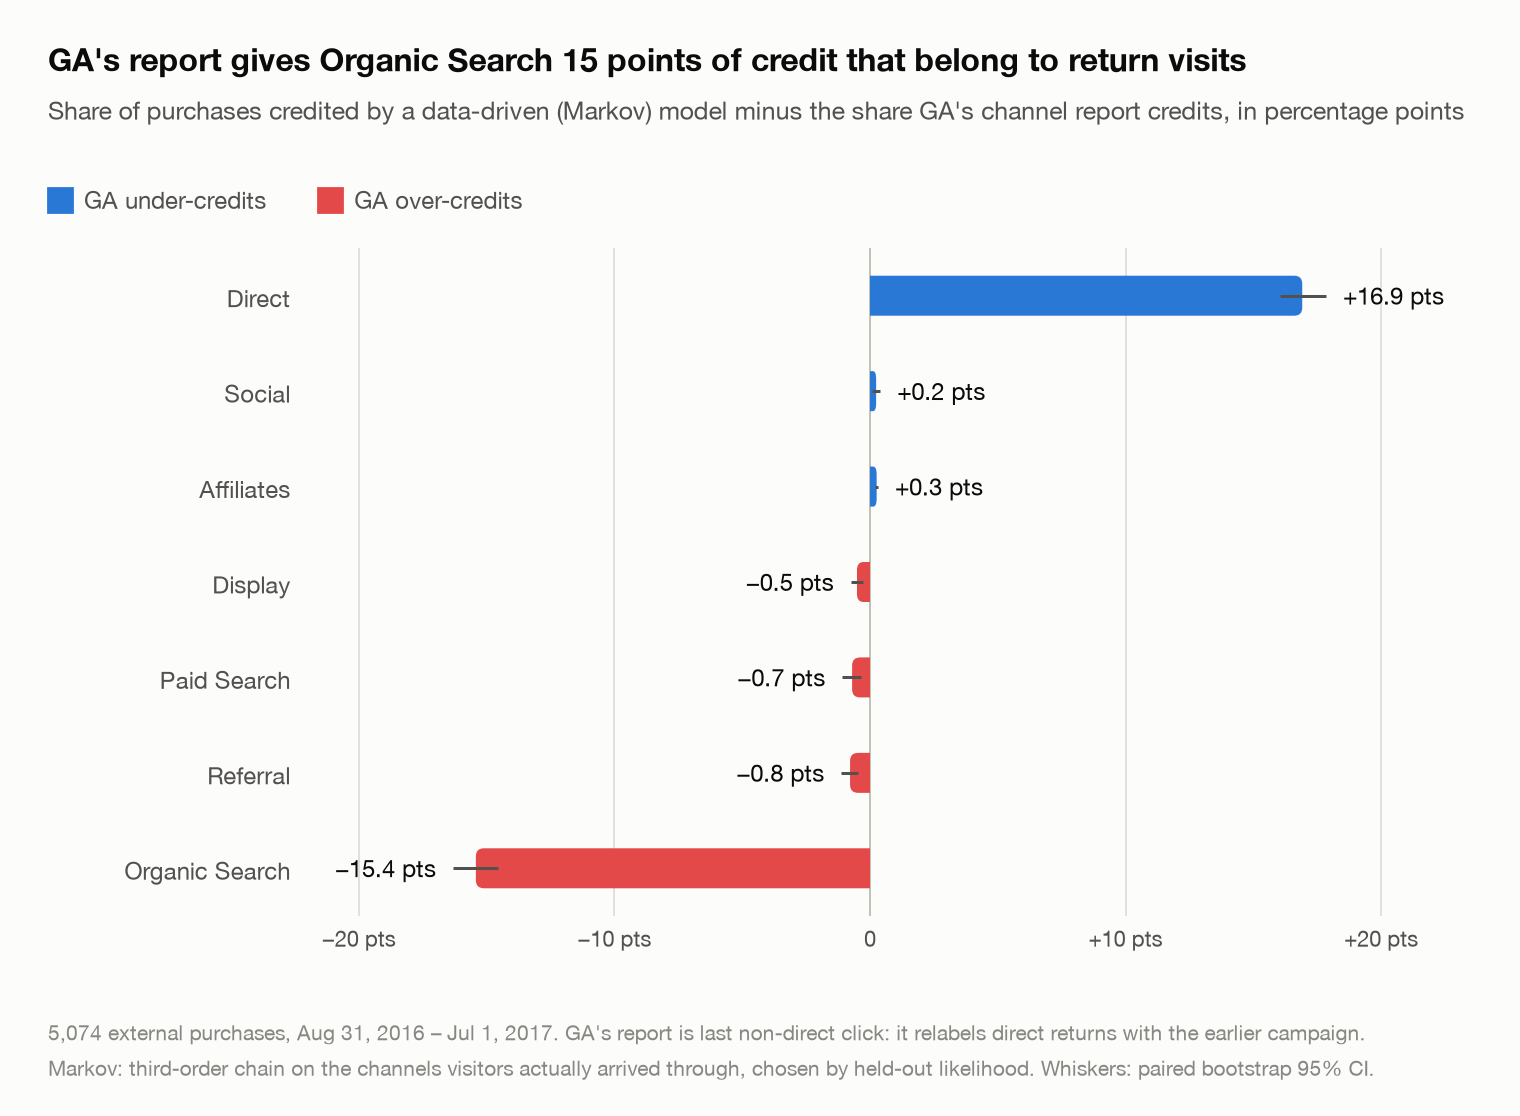

In [8]:
gap = h2.xs("vs GA report", axis=1, level=1)   # the join above drops the level names
chart_order = ["Direct", "Social", "Affiliates", "Display", "Paid Search", "Referral", "Organic Search"]
fig = viz.diverging_ci_chart(
    chart_order, gap.loc[chart_order, "markov_minus_ref_pts"].tolist(),
    gap.loc[chart_order, "ci_low"].tolist(), gap.loc[chart_order, "ci_high"].tolist(),
    title="GA's report gives Organic Search 15 points of credit that belong to return visits",
    subtitle="Share of purchases credited by a data-driven (Markov) model minus the share GA's channel report credits, in percentage points",
    note=(f"{len(conv):,} external purchases, Aug 31, 2016 – Jul 1, 2017. GA's report is last non-direct click: it relabels direct returns with the earlier campaign.\n"
          "Markov: third-order chain on the channels visitors actually arrived through, chosen by held-out likelihood. Whiskers: paired bootstrap 95% CI."),
    pos_label="GA under-credits", neg_label="GA over-credits",
    value_fmt=lambda v: f"{v:+.1f} pts", tick_fmt=lambda t: f"{t:+.0f} pts",
)
viz.show_saved(fig, ROOT / "reports/figures/d1_credit_gap.png")

**H2 depends on which "last click" is meant.**

- **Against true last click (last touch), H2 holds.** The data-driven model gives every journey-starting channel *more* credit: Organic Search +8.3 points, Paid Search +1.2, Display +0.4, Social +0.7, all with intervals above zero.
- **Against GA's actual report, it's reversed.** GA's last-*non-direct* rule hands the credit of later direct returns back to the first campaign, which **over-credits** the starters: Organic Search by 15.4 points, Paid Search by 0.7, and Display by 0.5. The channel GA under-credits is **Direct** (+16.9 points): returning visitors who come back on their own.

## 6. Sensitivity

In [9]:
conservative = Attribution(journeys, "conservative_path", order=MARKOV_ORDER)
revenue_shares = att.shares(measure="revenue")
sens = pd.DataFrame({
    "GA report (purchases)": shares["ga_last_click"],
    "Markov (purchases)": shares["markov"],
    "Markov, conservative relabel (purchases)": conservative.shares()["markov"],
    "GA report (capped revenue)": revenue_shares["ga_last_click"],
    "Markov (capped revenue)": revenue_shares["markov"],
}).loc[order]
sens.style.format("{:.1%}")

,GA report (purchases),Markov (purchases),"Markov, conservative relabel (purchases)",GA report (capped revenue),Markov (capped revenue)
Organic Search,53.6%,38.2%,45.4%,37.8%,27.0%
Direct,32.5%,49.4%,40.6%,46.8%,61.5%
Paid Search,7.4%,6.7%,7.6%,5.7%,5.2%
Referral,3.0%,2.2%,2.8%,4.5%,2.5%
Display,1.9%,1.4%,1.9%,4.4%,1.6%
Social,1.5%,1.8%,1.4%,0.9%,1.7%
Affiliates,0.1%,0.3%,0.1%,0.0%,0.4%


- **Conservative relabel** (only visits whose source is literally `(direct)` count as direct): Organic Search still gets far less than in GA's report (45% vs 54%). But **Paid Search and Display land at about GA's level**. The evidence that GA over-credits the paid channels therefore depends on how the `isTrueDirect` return visits are read.
- **Revenue credit** (Markov with each step into a purchase carrying the average order value that follows it): Direct's share rises further, to 61%, because the largest orders come from people returning on their own.

## 7. What is one paid click worth?

For budgeting, the question is revenue per **visit the channel actually brought**, which for paid channels is revenue per ad click. The denominator is the same for every model: arrival visits, not GA's relabelled session counts.

In [10]:
clicks = touches.arrival_channel.value_counts()
credited = att.credit_table().xs("revenue", axis=1, level="measure")[MODELS].copy()
credited["markov_conservative"] = conservative.credit_table()[("markov", "revenue")]
paid = ["Paid Search", "Display", "Affiliates"]
per_click = credited.loc[paid].div(clicks.loc[paid], axis=0).T
per_click.index = [names.get(m, "Markov, conservative relabel") for m in per_click.index]
display(per_click.style.format("${:.2f}"))
print("Break-even cost per click at a 50% gross margin = half of these values.")

,Paid Search,Display,Affiliates
GA report,$2.21,$9.08,$0.01
Last touch,$1.56,$2.89,$0.00
First touch,$2.08,$2.96,$0.01
Linear,$1.78,$2.85,$0.00
Position-based,$1.81,$2.90,$0.00
Markov (data-driven),$2.02,$3.31,$0.28
"Markov, conservative relabel",$2.46,$8.15,$0.07


Break-even cost per click at a 50% gross margin = half of these values.


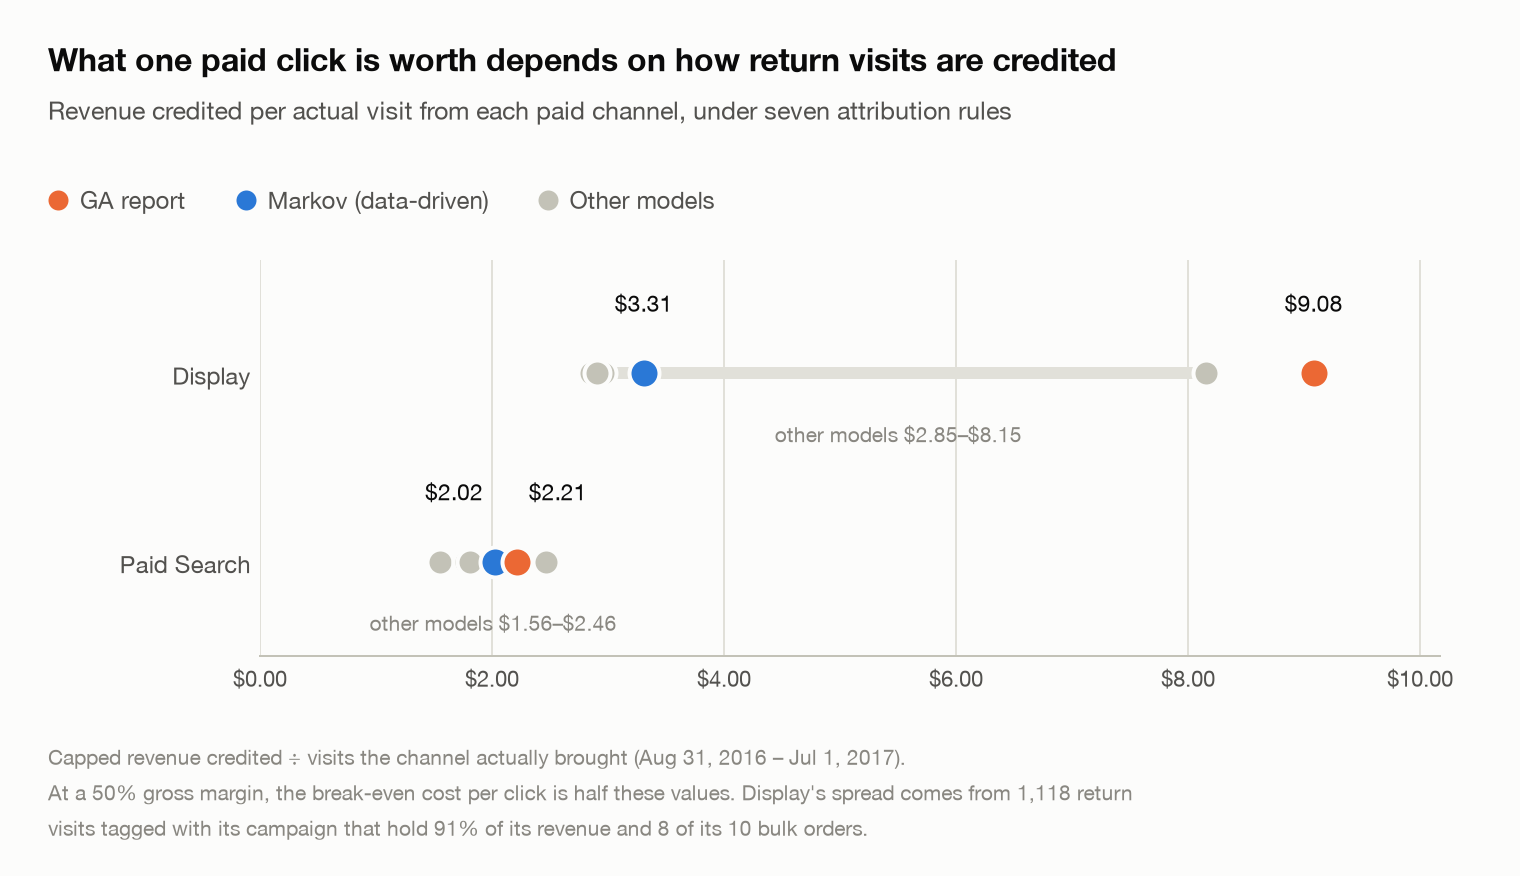

In [11]:
labels = {**names, "markov_conservative": "Markov, conservative relabel"}
points = {g: {labels[m]: credited.loc[g, m] / clicks.loc[g] for m in credited.columns} for g in ["Display", "Paid Search"]}
fig = viz.value_strip_chart(
    ["Display", "Paid Search"], points, {"GA report": "#eb6834", "Markov (data-driven)": viz.SERIES_1},
    title="What one paid click is worth depends on how return visits are credited",
    subtitle="Revenue credited per actual visit from each paid channel, under seven attribution rules",
    note=("Capped revenue credited ÷ visits the channel actually brought (Aug 31, 2016 – Jul 1, 2017).\n"
          "At a 50% gross margin, the break-even cost per click is half these values. Display's spread comes from 1,118 return\n"
          "visits tagged with its campaign that hold 91% of its revenue and 8 of its 10 bulk orders."),
)
viz.show_saved(fig, ROOT / "reports/figures/d1_value_per_click.png")

Why Display's value swings: most of what GA credits to Display comes from visits flagged `isTrueDirect` that carry Display's campaign tag. GA sets that flag both for true direct returns *and* for consecutive visits with identical campaign details, and the data can't tell which is which.

In [12]:
disp = touches[touches.ga_channel == "Display"]
disp.assign(visit=disp.is_true_direct.map({False: "fresh ad click", True: "isTrueDirect visit with Display's tag"})) \
    .groupby("visit").agg(visits=("purchased", "size"), purchases=("purchased", "sum"), revenue=("revenue_usd", "sum"),
                          bulk_orders=("revenue_usd", lambda r: int((r > 1606).sum()))) \
    .style.format({"visits": "{:,}", "revenue": "${:,.0f}"})

,visits,purchases,revenue,bulk_orders
visit,,,,
fresh ad click,"3,283",50,"$10,717",2
isTrueDirect visit with Display's tag,"1,118",47,"$113,765",8


In [13]:
orders = touches[touches.purchased]
bulk = orders[orders.revenue_usd > 1606]
print(f"Bulk orders (> $1,606): {len(bulk)} orders, ${bulk.revenue_usd.sum():,.0f} = "
      f"{bulk.revenue_usd.sum() / orders.revenue_usd.sum():.1%} of external revenue in the period")
bulk.groupby("ga_channel").revenue_usd.agg(orders="size", revenue="sum", median_order="median") \
    .sort_values("revenue", ascending=False).style.format({"revenue": "${:,.0f}", "median_order": "${:,.0f}"})

Bulk orders (> $1,606): 51 orders, $248,552 = 29.2% of external revenue in the period


,orders,revenue,median_order
ga_channel,,,
Display,10,"$110,728","$3,354"
Direct,26,"$98,189","$2,441"
Organic Search,14,"$37,266","$2,217"
Referral,1,"$2,370","$2,370"


In [14]:
split = credited.loc[paid] / credited.loc[paid].sum()
split.columns = [labels[m] for m in split.columns]
print("Paid budget split if paid spend followed credited revenue:")
split.T.style.format("{:.0%}")

Paid budget split if paid spend followed credited revenue:


,Paid Search,Display,Affiliates
GA report,57%,43%,0%
Last touch,74%,26%,0%
First touch,79%,21%,0%
Linear,77%,23%,0%
Position-based,77%,23%,0%
Markov (data-driven),72%,22%,6%
"Markov, conservative relabel",61%,38%,1%


## What this means for D1

1. **GA's report inflates Organic Search** by about 15 points of purchase credit, which really belongs to people coming back on their own. This holds under every model and the conservative relabel. Organic Search *starts* many journeys, but its reported share includes return visits it didn't cause.
2. **Returning visitors (Direct) are the store's biggest source of purchases and revenue** (49% of purchases and 61% of revenue in the data-driven model), and GA's channel report hides this. The Act phase should treat retention (email, reminders to past buyers) as a lever in its own right.
3. **Paid Search is roughly as valuable as GA says:** $1.56–$2.46 per click across models, so it breaks even below about **$0.80–$1.20 per click** at a 50% margin. Keep it, and bid against those numbers.
4. **Display can't be judged from this data.** Its value per click is $2.9–$9.1 depending on how 1,118 tagged return visits are credited, and 8 of the 10 bulk orders credited to Display (worth $111k together) sit in those visits. **Don't move Display budget on attribution alone. Run a holdout test first.**
5. **Affiliates and Social (YouTube) bring almost no purchases** under any model. If the store pays for either, the case would have to be something other than direct sales.

**Limitations.** Every model here, the Markov chain included, describes observed paths. None measures what a channel *causes* (incrementality); only experiments can. Cookie-based identity splits journeys across devices, which undercounts multi-visit paths. There's no cost data, so budget advice is framed as the maximum affordable cost per click.